In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io.arff import loadarff 

### adult census dataset

In [2]:
data, metadata = loadarff("../datasets/adult_census.arff")
adult_census = pd.DataFrame(data)
# removing b' '
for col in adult_census.select_dtypes(include="object"):
    adult_census[col] = adult_census[col].str.decode("utf-8")
adult_census_all = adult_census.copy()
# numerical dataset
adult_census = adult_census[['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'class']]
adult_census

,age,capital-gain,capital-loss,hours-per-week,class
0,25.0,0.0,0.0,40.0,<=50K
1,38.0,0.0,0.0,50.0,<=50K
2,28.0,0.0,0.0,40.0,>50K
3,44.0,7688.0,0.0,40.0,>50K
4,18.0,0.0,0.0,30.0,<=50K
...,...,...,...,...,...
48837,27.0,0.0,0.0,38.0,<=50K
48838,40.0,0.0,0.0,40.0,>50K
48839,58.0,0.0,0.0,40.0,<=50K
48840,22.0,0.0,0.0,20.0,<=50K


In [3]:
X, y = adult_census.drop(columns=['class']), adult_census['class']

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# learn mean/variance from training data AND scale it
X_train_scaled = scaler.fit_transform(X_train)
# scale test data using the training parameters (NOT refit!)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 2.35103321, -0.14421841, -0.22013749, -1.8892569 ],
       [-1.57914384, -0.14421841, -0.22013749, -2.45304549],
       [-0.85133328, -0.14421841, -0.22013749, -0.03680866],
       ...,
       [-0.19630377, -0.14421841, -0.22013749, -0.03680866],
       [-0.487428  , -0.14421841, -0.22013749, -0.03680866],
       [-0.63299011, -0.14421841, -0.22013749, -0.03680866]],
      shape=(39073, 4))

### KNN classifier

In [6]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

model.fit(X_train, y_train)
y_pred_unscaled = model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
knn_scaled_acc = accuracy_score(y_test, y_pred)
knn_unscaled_acc = accuracy_score(y_test, y_pred_unscaled)
knn_scaled_acc, knn_unscaled_acc

(0.8017197256628109, 0.8161531374756884)

In [8]:
from sklearn.metrics import classification_report

# reveals how well the model actually catches high earners (>50K)
print(classification_report(y_test, y_pred))

print('\n\n' + '-'*23 + 'UNSCALED' + '-'*23)
print(classification_report(y_test, y_pred_unscaled))

              precision    recall  f1-score   support

       <=50K       0.83      0.93      0.88      7431
        >50K       0.64      0.39      0.48      2338

    accuracy                           0.80      9769
   macro avg       0.74      0.66      0.68      9769
weighted avg       0.78      0.80      0.78      9769



-----------------------UNSCALED-----------------------
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      7431
        >50K       0.69      0.43      0.53      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.68      0.71      9769
weighted avg       0.80      0.82      0.80      9769



### random forest classifier

In [9]:
from sklearn.ensemble import RandomForestClassifier

r_forest = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

In [10]:
r_forest.fit(X_train_scaled, y_train)
y_pred_rforest = r_forest.predict(X_test_scaled)

r_forest.fit(X_train, y_train)
y_pred_rforest_unscaled = r_forest.predict(X_test)

In [11]:
rforest_scaled_acc = accuracy_score(y_test, y_pred_rforest)
rforest_unscaled_acc = accuracy_score(y_test, y_pred_rforest_unscaled)
rforest_scaled_acc, rforest_unscaled_acc

(0.8237281195618794, 0.8237281195618794)

In [12]:
print(classification_report(y_test, y_pred_rforest))

print('\n\n' + '-'*23 + 'UNSCALED' + '-'*23)
print(classification_report(y_test, y_pred_rforest_unscaled))

              precision    recall  f1-score   support

       <=50K       0.81      1.00      0.90      7431
        >50K       0.97      0.27      0.43      2338

    accuracy                           0.82      9769
   macro avg       0.89      0.63      0.66      9769
weighted avg       0.85      0.82      0.78      9769



-----------------------UNSCALED-----------------------
              precision    recall  f1-score   support

       <=50K       0.81      1.00      0.90      7431
        >50K       0.97      0.27      0.43      2338

    accuracy                           0.82      9769
   macro avg       0.89      0.63      0.66      9769
weighted avg       0.85      0.82      0.78      9769



### HistGradientBoostingClassifier (from Gmini)

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize and train
gb_model = HistGradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train) # Use unscaled data

# Predict and evaluate
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))
accuracy_score(y_test, y_pred_gb)

              precision    recall  f1-score   support

       <=50K       0.82      1.00      0.90      7431
        >50K       0.96      0.31      0.47      2338

    accuracy                           0.83      9769
   macro avg       0.89      0.65      0.68      9769
weighted avg       0.85      0.83      0.80      9769



0.8317125601392159

### bringing back all the data, RANDOM FOREST

In [28]:
X_all, y_all = adult_census_all.drop(columns=['class']), adult_census_all['class']
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y)

In [30]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Identify which columns contain text strings
cat_cols = X_train_all.select_dtypes(include=['object']).columns

# 2. Initialize encoder (handles unexpected or unseen values safely)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Transform text categories to numbers for both sets
X_train_all[cat_cols] = encoder.fit_transform(X_train_all[cat_cols])
X_test_all[cat_cols] = encoder.transform(X_test_all[cat_cols])
X_train_all

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
34342,71.0,4.0,77253.0,11.0,9.0,4.0,6.0,1.0,4.0,1.0,0.0,0.0,17.0,39.0
18559,17.0,4.0,329783.0,0.0,6.0,4.0,12.0,2.0,4.0,0.0,0.0,0.0,10.0,39.0
12477,27.0,4.0,91257.0,11.0,9.0,2.0,8.0,0.0,4.0,1.0,0.0,0.0,40.0,8.0
560,43.0,4.0,125577.0,11.0,9.0,5.0,1.0,4.0,2.0,0.0,0.0,0.0,40.0,39.0
3427,31.0,4.0,137978.0,9.0,13.0,2.0,4.0,0.0,4.0,1.0,0.0,0.0,40.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38073,33.0,4.0,217460.0,11.0,9.0,2.0,12.0,0.0,4.0,1.0,0.0,0.0,60.0,39.0
16306,56.0,2.0,216851.0,9.0,13.0,2.0,13.0,0.0,4.0,1.0,0.0,0.0,40.0,39.0
26860,36.0,4.0,136629.0,15.0,10.0,2.0,7.0,0.0,4.0,1.0,0.0,0.0,40.0,39.0
20602,32.0,4.0,80058.0,11.0,9.0,2.0,1.0,0.0,4.0,1.0,0.0,0.0,40.0,39.0


In [31]:
r_forest_2 = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

In [32]:
r_forest_2.fit(X_train_all, y_train_all)
y_pred_all = r_forest_2.predict(X_test_all)

In [33]:
print(accuracy_score(y_test_all, y_pred_all))
print(classification_report(y_test_all, y_pred_all))

0.8563824342307299
              precision    recall  f1-score   support

       <=50K       0.86      0.97      0.91      7431
        >50K       0.82      0.51      0.63      2338

    accuracy                           0.86      9769
   macro avg       0.84      0.74      0.77      9769
weighted avg       0.85      0.86      0.84      9769



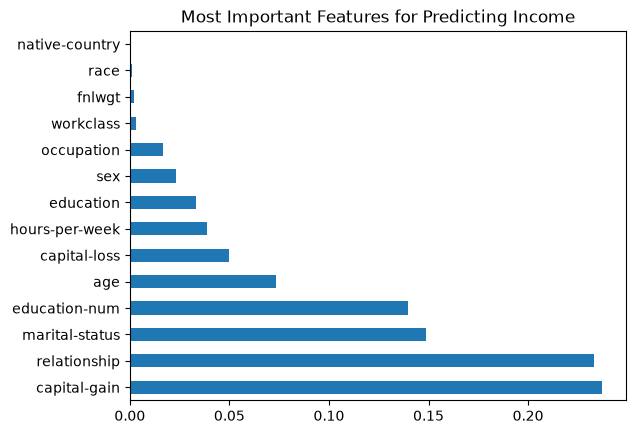

In [34]:
# Extract and sort feature importances
importances = pd.Series(r_forest_2.feature_importances_, index=X_train_all.columns)
importances.sort_values(ascending=False).plot(kind='barh')
plt.title("Most Important Features for Predicting Income")
plt.show()